### **STEP 0: Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

### **STEP 1: Understanding the Problem and the Data**

In [2]:
# Goal:
# Predict survival of passengers based on features like age, gender, class, etc.

print("Goal: Analyze factors affecting passenger survival on Titanic")

Goal: Analyze factors affecting passenger survival on Titanic


### **STEP 2: Importing and Inspecting the Data**

In [3]:
# Load dataset (from seaborn library)
df = sns.load_dataset('titanic')

In [4]:
# View first 5 rows
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [5]:
# Check shape
print("\nShape of dataset:", df.shape)


Shape of dataset: (891, 15)


In [6]:
# Check column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [7]:
# Check data types and missing values
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [8]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


### **STEP 3: Handling Missing Data**

In [9]:
# Fill missing Age with median
df['age'].fillna(df['age'].median(), inplace=True)

/tmp/ipykernel_1370/4217510574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [10]:
# Fill Embarked with most frequent value
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

/tmp/ipykernel_1370/1174326362.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


In [12]:
# Drop column with too many missing values (deck)
df.drop(columns=['deck'], inplace=True)

In [14]:
# Verify missing values again
print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


### **STEP 4: Exploring Data Characteristics**

In [15]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


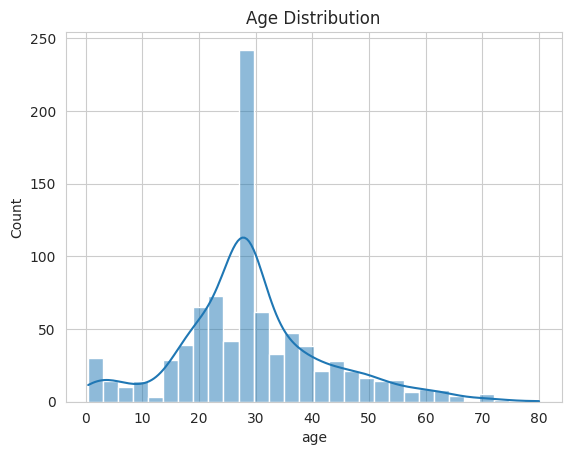

In [16]:
# Check distribution of Age
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [17]:
# Check skewness
print("\nSkewness:")
print(df.skew(numeric_only=True))


Skewness:
survived      0.478523
pclass       -0.630548
age           0.510245
sibsp         3.695352
parch         2.749117
fare          4.787317
adult_male   -0.420431
alone        -0.420431
dtype: float64


### **STEP 5: Performing Data Transformation**

In [18]:
# Encoding categorical variable (sex)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

In [19]:
# One-hot encoding for embarked
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [20]:
# Feature engineering: Family size
df['family_size'] = df['sibsp'] + df['parch']

In [21]:
print("\nTransformed Data Sample:")
print(df.head())


Transformed Data Sample:
   survived  pclass  sex   age  sibsp  parch     fare  class    who  \
0         0       3    0  22.0      1      0   7.2500  Third    man   
1         1       1    1  38.0      1      0  71.2833  First  woman   
2         1       3    1  26.0      0      0   7.9250  Third  woman   
3         1       1    1  35.0      1      0  53.1000  First  woman   
4         0       3    0  35.0      0      0   8.0500  Third    man   

   adult_male  embark_town alive  alone  embarked_Q  embarked_S  family_size  
0        True  Southampton    no  False       False        True            1  
1       False    Cherbourg   yes  False       False       False            1  
2       False  Southampton   yes   True       False        True            0  
3       False  Southampton   yes  False       False        True            1  
4        True  Southampton    no   True       False        True            0  


### **STEP 6: Visualizing Relationship of Data**

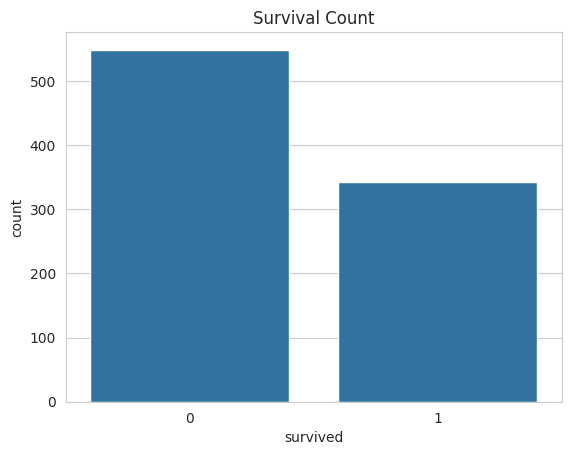

In [22]:
# Survival count
plt.figure()
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

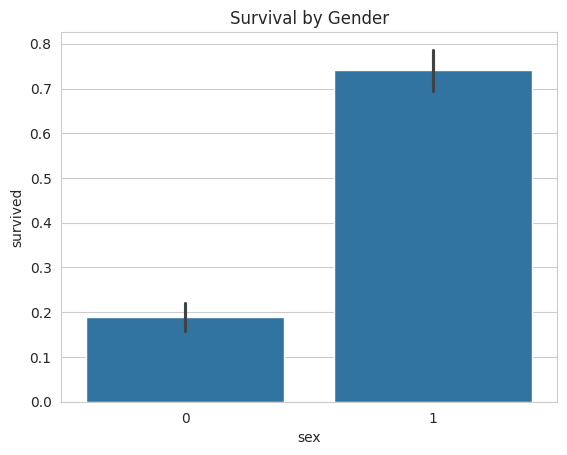

In [23]:
# Survival by gender
plt.figure()
sns.barplot(x='sex', y='survived', data=df)
plt.title("Survival by Gender")
plt.show()

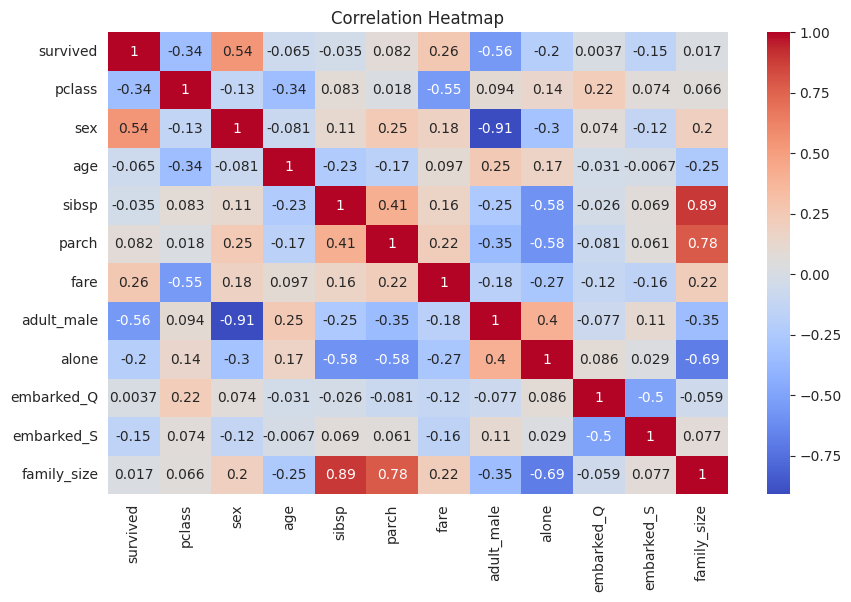

In [24]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### **STEP 7: Handling Outliers**

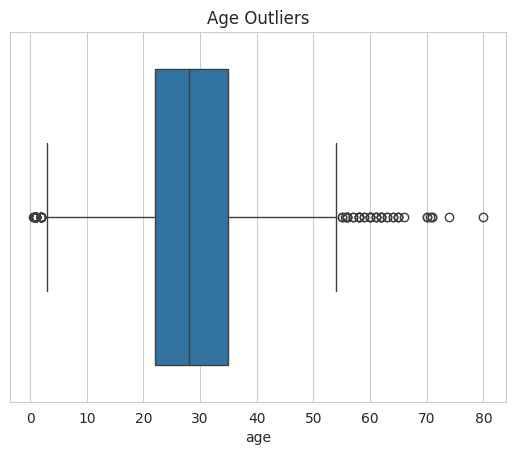

In [25]:
# Boxplot to detect outliers in age
plt.figure()
sns.boxplot(x=df['age'])
plt.title("Age Outliers")
plt.show()

In [26]:
# Remove extreme outliers using IQR
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['age'] >= Q1 - 1.5 * IQR) & (df['age'] <= Q3 + 1.5 * IQR)]

print("\nShape After Removing Outliers:", df.shape)


Shape After Removing Outliers: (825, 16)


### **STEP 8: Communicate Findings and Insights**

In [27]:
print("\nKey Insights:")

print("- Females had higher survival rate than males.")
print("- Younger passengers had slightly better survival chances.")
print("- Passenger class impacts survival (higher class = better survival).")
print("- Family size also influences survival.")

print("\nLimitations:")
print("- Missing data imputation may introduce bias.")
print("- Dataset is relatively small.")

print("\nNext Steps:")
print("- Apply machine learning models.")
print("- Perform feature selection.")
print("- Tune models for better accuracy.")


Key Insights:
- Females had higher survival rate than males.
- Younger passengers had slightly better survival chances.
- Passenger class impacts survival (higher class = better survival).
- Family size also influences survival.

Limitations:
- Missing data imputation may introduce bias.
- Dataset is relatively small.

Next Steps:
- Apply machine learning models.
- Perform feature selection.
- Tune models for better accuracy.
